In [1]:
import numpy as np
import pandas as pd

from smooth import ADAM

df = pd.read_csv("../data/etsx_data.csv")

y = df["y"]
X = df[["x1", "x2"]]

model = ADAM(model="AAN", regressors="use", h=5, holdout=True, smoother="global")
model.fit(y, X)


print(model.summary())

model.predict(5, X.tail(5))



Model estimated using ADAM() function: ETSX(AAN)
Response variable: y
Distribution used in the estimation: Normal
Loss function type: likelihood; Loss function value: 157.4708
Coefficients:
       Estimate  Std. Error  Lower 2.5%  Upper 97.5%   
alpha    0.0223      0.0200      0.0000       0.0619   
beta     0.0000      0.0002      0.0000       0.0003   
xreg1    1.8859      0.0875      1.7126       2.0591  *
xreg2   -1.4746      0.0996     -1.6718      -1.2774  *
Error standard deviation: 0.9516
Sample size: 115
Number of estimated parameters: 5
Number of degrees of freedom: 110
Information criteria:
     AIC    AICc      BIC     BICc
324.9415 325.492 338.6662 339.9721


          mean
115   9.499318
116   6.680249
117  14.756861
118   6.690754
119  11.260099

In [2]:
from fcompdata import M3
from smooth import ADAM

series = M3[2568]

# Fit model
model = ADAM(model="ZXZ", lags=[1,series.period],
            #  ar_order=[1,1], i_order=[1,1], ma_order=[1,2],
             initial="backcasting",
             nlopt_kargs={"print_level": 0,
                          "maxeval": 0},
             holdout=True, h=18)

model.fit(series.x)

print(model)

model.plot(7)

KeyboardInterrupt: 

In [ ]:
from fcompdata import M3
from smooth import AutoADAM

series = M3[2568]

# Fit model
model = AutoADAM(model="ANN", lags=[1,series.period],
                 orders={"ar": [3,3], "i": [2,2], "ma": [3,3]},
                 arima_select=True,
                 initial="backcasting",
                 nlopt_kargs={"print_level": 0,
                              "maxeval": 1})

model.fit(series.x)

print(model)

Time elapsed: 3.69 seconds
Model estimated using ADAM() function: ETS(ANN)+SARIMA(3,0,0)[1](0,1,1)[12] with drift
With backcasting initialisation
Distribution assumed in the model: Log-Normal
Loss function type: likelihood; Loss function value: 872.0257
Intercept/Drift value: 77.6781
Persistence vector g:
 alpha
0.0047
ARMA parameters of the model:
             Lag 1
AR(1)       0.0339
AR(2)       0.1965
AR(3)       0.4795
            Lag 12
MA(1)      -0.1571
Sample size: 116
Number of estimated parameters: 7
Number of degrees of freedom: 109
Information criteria:
      AIC      AICc       BIC      BICc
1758.0513 1759.0883 1777.3264 1779.7913


In [ ]:
from fcompdata import M3
from smooth import ES

series = M3[2568]

# Fit model
model = ES(model="ZXZ", lags=[series.period],
             holdout=True, h=18, initial="optimal")

model.fit(series.x)

# print(model)

model.predict(h=18, interval="prediction")

model.summary()

# model.plot(7)


,b1,b2,b3,b4,b5,b6,b7,b8,b9,b10,b11,b12,b13,b14,b15,b16
b1,0.009355,0.000510,0.003355,-3.346033,-0.850278,0.000282,-6.372859e-04,-0.000324,8.203940e-04,3.110076e-04,1.250897e-04,-0.000293,-0.000280,0.000210,0.000077,0.000133
b2,0.000510,0.000012,0.000142,-0.465836,-0.022362,0.000017,-2.159729e-05,-0.000015,3.032981e-05,1.057724e-05,2.346892e-06,-0.000012,-0.000012,0.000007,0.000004,0.000006
b3,0.003355,0.000142,-0.003935,-1.825990,-0.234060,-0.000036,6.065325e-04,0.000161,-5.124013e-04,-2.990548e-04,-2.377099e-05,0.000160,0.000265,-0.000239,-0.000131,-0.000172
b4,-3.346033,-0.465836,-1.825990,4778.995196,625.756744,-0.123110,5.268749e-01,0.154317,-8.332828e-01,-2.048296e-01,-2.590819e-01,0.205650,0.183800,-0.205850,0.035566,0.024987
b5,-0.850278,-0.022362,-0.234060,625.756744,42.307395,-0.029180,3.614359e-02,0.026630,-5.078625e-02,-1.581218e-02,-4.632760e-03,0.020797,0.019596,-0.012878,-0.006499,-0.010197
b6,0.000282,0.000017,-0.000036,-0.123110,-0.029180,0.000389,-3.151326e-05,-0.000043,5.353702e-06,-4.650231e-05,-8.457662e-06,-0.000035,-0.000030,-0.000012,-0.000033,-0.000035
b7,-0.000637,-0.000022,0.000607,0.526875,0.036144,-0.000032,2.569408e-04,-0.000068,4.467369e-05,5.299253e-07,-3.036375e-05,-0.000065,-0.000080,0.000003,-0.000021,-0.000016
b8,-0.000324,-0.000015,0.000161,0.154317,0.026630,-0.000043,-6.780630e-05,0.000415,-2.650314e-05,-4.010277e-05,-4.277261e-05,-0.000052,-0.000056,-0.000033,-0.000041,-0.000041
b9,0.000820,0.000030,-0.000512,-0.833283,-0.050786,0.000005,4.467369e-05,-0.000027,4.269588e-04,-8.778767e-05,5.804569e-07,-0.000017,0.000004,-0.000032,-0.000049,-0.000058
b10,0.000311,0.000011,-0.000299,-0.204830,-0.015812,-0.000047,5.299253e-07,-0.000040,-8.778767e-05,3.824893e-04,-4.948972e-05,-0.000038,-0.000029,-0.000066,-0.000059,-0.000063


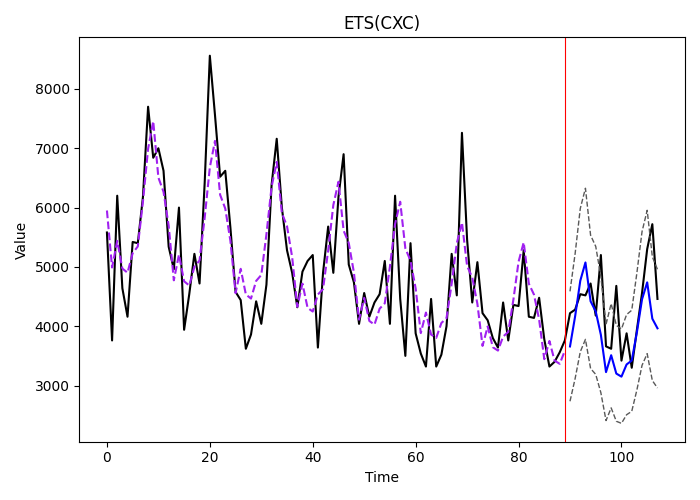

In [ ]:
from fcompdata import M3
from smooth import ES

series = M3[1687]

# Fit model
model = ES(model="CXC", lags=[series.period],
             holdout=True, h=18)

model.fit(series.x)

# print(model)

model.predict(h=18, interval="prediction")

model.plot(7)



In [ ]:
from smooth import ES
from fcompdata import PromoData

model = ES(model="MNM", lags=52, holdout=True, h=13)
model.fit(PromoData.y)
model.predict(h=18)
model.plot(7)

# model.summary()


Model estimated using ES() function: ETS(MNM)
Response variable: y
Distribution used in the estimation: Normal
Loss function type: likelihood; Loss function value: 1045.8568
Coefficients:
       Estimate  Std. Error  Lower 2.5%  Upper 97.5%   
alpha    0.2086      0.0493      0.1112       0.3059  *
gamma    0.0000      0.0622      0.0000       0.1230   
Error standard deviation: 0.1542
Sample size: 143
Number of estimated parameters: 3
Number of degrees of freedom: 140
Information criteria:
AIC     2097.7136
AICc    2097.8862
BIC     2106.6021
BICc    2107.0305

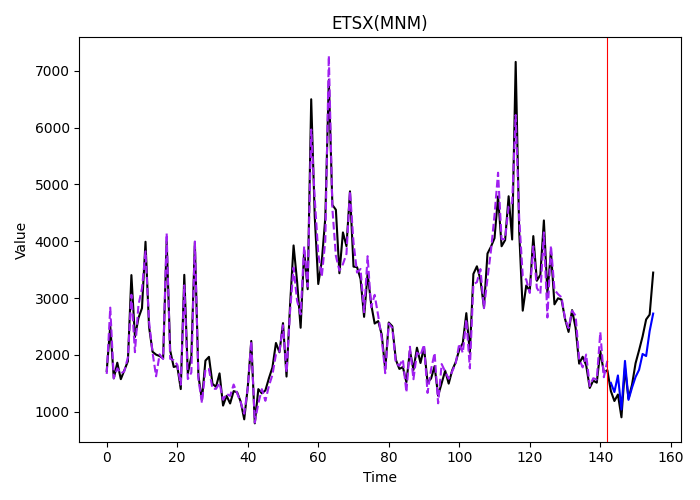

In [ ]:
from smooth import ADAM
from fcompdata import PromoData

model = ADAM(model="MNM", lags=52, holdout=True, h=13)
model.fit(PromoData.y, PromoData.xreg)
model.predict(h=13, X=PromoData.xregxx)
model.plot(7)

Evaluating models with different distributions... dnorm, dlaplace, ds, dgnorm, dlnorm, dinvgauss, dgamma, Done!
Selected distribution: dnorm


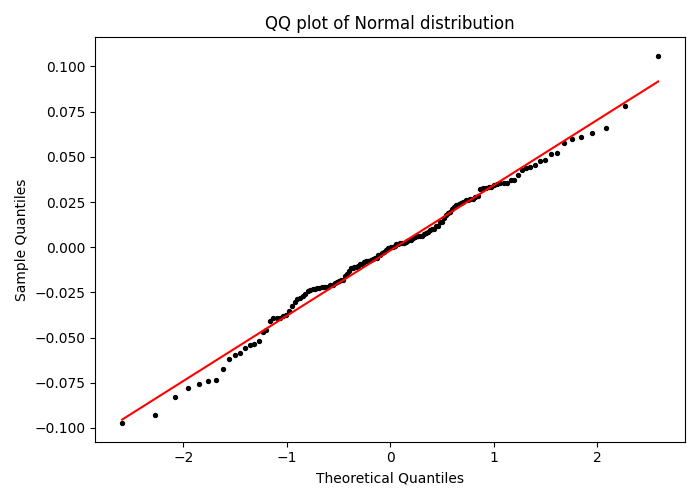

In [4]:
from fcompdata import AirPassengers
from smooth import AutoADAM, ADAM

model = AutoADAM(lags=[12], h=12, holdout=False, orders=None, verbose=True)
# model = ADAM(lags=[12], h=12, holdout=False, orders=None, verbose=True, distribution="dgnorm", initial="optimal")
model.fit(AirPassengers.y)
# model.summary()
model.plot(6)